In [273]:
# Import required libraries
import seaborn as sns          # For data visualization (not used yet, but useful later)
import pandas as pd            # For data manipulation and analysis
import numpy as np             # For numerical operations
import logging                 # For logging messages (not used yet)
from pathlib import Path       # For handling file paths in a clean way


# This is the folder where all your CSV files are stored
DATA_DIR = Path("python_project_aiml_logicmojo_dataset")


# Dictionary mapping dataset names to file names
FILES = {
    "customers": "customers.csv",
    "products": "products.csv",
    "orders": "orders.csv",
    "order_items": "order_item.csv",
    "payments": "payments.csv",
    "locations": "location.csv",
    "category_translations": "category_translation.csv",
    "sellers": "sellers.csv",
    "reviews": "reviews.csv"
}


#------------------------#
# Load Datasets
#------------------------#
# Create an empty dictionary to store all datasets
datasets = {}

# Loop through each file and load it into a pandas DataFrame
for name, file in FILES.items():
    file_path = DATA_DIR / file        # Create full file path
    df = pd.read_csv(file_path)        # Read CSV file into DataFrame
    datasets[name] = df                # Store DataFrame in dictionary
    
    # Print dataset name and shape (rows, columns)
    print(f"Dataset {name} is loaded, shape: {df.shape}")


#------------------------#
# Explore Datasets
#------------------------#
# Loop through each dataset for basic exploration
for name, df in datasets.items():

    print(f"\n{'='*50}")
    print(f"Exploring Dataset: {name}")
    print(f"{'='*50}")

    # Display first 5 rows
    print("\n First 5 rows:")
    print(df.head())

    # Display dataset structure (columns, data types, null values)
    print("\n Info:")
    print(df.info())

    # Display statistical summary
    # include="all" ensures categorical columns are also summarized
    print("\n Statistical Summary:")
    print(df.describe(include="all"))

Dataset customers is loaded, shape: (99441, 5)
Dataset products is loaded, shape: (32951, 9)
Dataset orders is loaded, shape: (99441, 8)
Dataset order_items is loaded, shape: (112650, 7)
Dataset payments is loaded, shape: (103886, 5)
Dataset locations is loaded, shape: (1000163, 5)
Dataset category_translations is loaded, shape: (71, 2)
Dataset sellers is loaded, shape: (3095, 4)
Dataset reviews is loaded, shape: (99224, 7)

Exploring Dataset: customers

 First 5 rows:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                  

In [274]:
# Standardize column names

for name,df in datasets.items():

    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(" ","_")
                  .str.replace("lenght","length"))

    print(f"Column names standardized for dataset: {name} => {df.columns}")



Column names standardized for dataset: customers => Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
Column names standardized for dataset: products => Index(['product_id', 'product_category_name', 'product_name_length',
       'product_description_length', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')
Column names standardized for dataset: orders => Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Column names standardized for dataset: order_items => Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
Column names standardized for dataset: pa

In [275]:
# Validate Datatypes & Ranges


# Event-based columns:
# These represent real-world events (like delivery, approval)
# Missing values (NaT) are meaningful → event did NOT happen yet
EVENT_COLS = {
    "orders": [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
}

# Loop through each dataset
for name, df in datasets.items():

    print("\n Dataset:", name)

    # Column-level checks
    for col in df.columns:

        # Check categorical columns (object type)
        if df[col].dtype == "object":
            # Count unique values → helps identify high-cardinality columns
            print(f"Unique values for categorical column {col}: {df[col].nunique()}")

        if df[col].dtype in ["int64", "float64"]:
            print(f"Datatype for {col}: {df[col].dtype}")
            print(f"Max value for {col}: {df[col].max()}")
            print(f"Min value for {col}: {df[col].min()}")

        # Convert date-like columns to datetime
        if (
            "date" in col
            or "timestamp" in col
            or "time" in col
            or "order_approved_at" in col
        ):
            # Convert to datetime, invalid parsing → NaT
            df[col] = pd.to_datetime(df[col], errors="coerce")

            # Check if it's an event column
            event_cols = EVENT_COLS.get(name, [])

            # Add note for event columns
            note = ": NaT retained for Event Based Columns" if col in event_cols else ""

            print(f"{col} converted to datetime{note}")

    # Negative value checks
    # These columns should NEVER have negative values
    non_negative_keywords = [
        "price", "weight", "length", "value",
        "height", "width", "installments", "score", "qty"
    ]

    # Select only numeric columns
    for col in df.select_dtypes(include="number").columns:

        if any(kw in col.lower() for kw in non_negative_keywords):
            negative_count = (df[col] < 0).sum()

            # Report if negatives exist
            if negative_count:
                print(f"Negative value(s): {negative_count} found for {col}")


    # Zero value checks
    # These columns should ideally NOT be zero
    non_zero_keywords = ["price", "payment_value", "freight_value"]

    for col in df.columns:
        if col in non_zero_keywords:
            zero_count = (df[col] == 0).sum()

            if zero_count:
                print(f"Zero value(s): {zero_count} found for {col}")


    # Business Rule Checks
    # Review score must be between 1 and 5
    if "review_score" in df.columns:
        invalid = df[~df["review_score"].between(1, 5)]

        if not invalid.empty:
            print(f"'review_score': {len(invalid)} value(s) found outside (1,5)")


    # Installments should not be zero
    if "payment_installments" in df.columns:
        zero_inst = (df["payment_installments"] == 0).sum()

        if zero_inst:
            print(f"'payment_installments': {zero_inst} record(s) found with 0 installments")

    # Geolocation Validation (Brazil dataset)
    # Latitude should be within Brazil bounds
    if "geolocation_lat" in df.columns:
        out_lat = df[~df["geolocation_lat"].between(-34, 6)]

        if not out_lat.empty:
            print(f"⚠️ geolocation_lat: {len(out_lat)} value(s) outside Brazil bounds [-34, 6].")

    # Longitude should be within Brazil bounds
    if "geolocation_lng" in df.columns:
        out_lng = df[~df["geolocation_lng"].between(-74, -28)]

        if not out_lng.empty:
            print(f"⚠️ geolocation_lng: {len(out_lng)} value(s) outside Brazil bounds [-74, -28].")


 Dataset: customers
Unique values for categorical column customer_id: 99441
Unique values for categorical column customer_unique_id: 96096
Datatype for customer_zip_code_prefix: int64
Max value for customer_zip_code_prefix: 99990
Min value for customer_zip_code_prefix: 1003
Unique values for categorical column customer_city: 4119
Unique values for categorical column customer_state: 27

 Dataset: products
Unique values for categorical column product_id: 32951
Unique values for categorical column product_category_name: 73
Datatype for product_name_length: float64
Max value for product_name_length: 76.0
Min value for product_name_length: 5.0
Datatype for product_description_length: float64
Max value for product_description_length: 3992.0
Min value for product_description_length: 4.0
Datatype for product_photos_qty: float64
Max value for product_photos_qty: 20.0
Min value for product_photos_qty: 1.0
Datatype for product_weight_g: float64
Max value for product_weight_g: 40425.0
Min value f

In [276]:

# Check for Duplicates in Datasets
# Loop through each dataset
for name, df in datasets.items():

    # Customers Dataset
    # customer_id should be UNIQUE (Primary Key)
    if "customer" in name:
        print("\nCustomer Dataset")

        # Find duplicate rows based on customer_id
        duplicate_customer = df[df.duplicated(subset=['customer_id'], keep=False)]
        # keep=False → marks ALL duplicates (not just second occurrence)
        print("Duplicate customer rows:", len(duplicate_customer))

    # Products Dataset
    # product_id should be UNIQUE
    if "products" in name:
        print("\nProducts Dataset")

        duplicate_product = df[df.duplicated(subset=['product_id'], keep=False)]
        print("Duplicate product rows:", len(duplicate_product))

    # Orders Dataset
    # order_id should be UNIQUE
    if "orders" in name:
        print("\nOrders Dataset")

        duplicate_order = df[df.duplicated(subset=['order_id'], keep=False)]
        print("Duplicate order rows:", len(duplicate_order))

    # Order Items Dataset
    # Composite key → (order_id + order_item_id)
    # Same order can have multiple items, so combination must be unique
    if "order_items" in name:
        print("\nOrder Items Dataset")

        duplicate_order_item = df[df.duplicated(
            subset=['order_id', 'order_item_id'], keep=False
        )]

        print("Duplicate order_item rows:", len(duplicate_order_item))

    # Payments Dataset
    # Composite key → (order_id + payment_sequential)
    # One order can have multiple payments
    if "payments" in name:
        print("\nPayments Dataset")

        duplicate_payment = df[df.duplicated(
            subset=['order_id', 'payment_sequential'], keep=False
        )]

        print("Duplicate payments rows:", len(duplicate_payment))

    # Locations Dataset
    # Instead of dropping duplicates blindly,
    # we AGGREGATE based on zip code
    if "locations" in name:
        print("\nLocations Dataset")

        before = len(df)

        # Group by zip code and aggregate
        df = df.groupby("geolocation_zip_code_prefix", as_index=False).agg({
            "geolocation_lat": "mean",     # average latitude
            "geolocation_lng": "mean",     # average longitude
            "geolocation_city": "first",   # take first city
            "geolocation_state": "first",  # take first state
        })

        after = len(df)

        # Rows reduced after aggregation
        print(f"=> Aggregated locations by zip code: {before - after} rows consolidated.")
        datasets[name] = df

    # Category Translations Dataset
    # product_category_name should be unique
    if "category_translations" in name:
        print("\nCategory Translations Dataset")

        duplicate_category_translations = df[df.duplicated(
            subset=['product_category_name'], keep=False
        )]

        print("Duplicate category_translations rows:", len(duplicate_category_translations))


    # Reviews Dataset
    # review_id should be unique
    if "reviews" in name:
        print("\nReviews Dataset")

        duplicate_reviews = df[df.duplicated(subset=['review_id'], keep=False)]
        print("Duplicate reviews rows:", len(duplicate_reviews))

        # Deduplication logic:
        # Keep the latest review based on timestamp
        before = len(df)

        df = df.sort_values("review_answer_timestamp").drop_duplicates(
            subset=["review_id"], keep="last"
        )

        removed = before - len(df)

        print(f"=> Deduplicated reviews on review_id: removed {removed} duplicate IDs.")
        datasets[name] = df


Customer Dataset
Duplicate customer rows: 0

Products Dataset
Duplicate product rows: 0

Orders Dataset
Duplicate order rows: 0

Order Items Dataset
Duplicate order_item rows: 0

Payments Dataset
Duplicate payments rows: 0

Locations Dataset
=> Aggregated locations by zip code: 981148 rows consolidated.

Category Translations Dataset
Duplicate category_translations rows: 0

Reviews Dataset
Duplicate reviews rows: 1603
=> Deduplicated reviews on review_id: removed 814 duplicate IDs.


In [277]:
# Handle Missing Values

# Columns to KEEP even if they have high missing values
# (Useful for NLP / text analysis → don't drop them)
KEEP_SPARSE_COLS = {
    "reviews": ["review_comment_title", "review_comment_message"]
}

# Loop through each dataset
for name, df in datasets.items():

    print(f"\nDataset: {name}")

    total_rows = len(df)

    # Get special column groups
    keep_sparse = KEEP_SPARSE_COLS.get(name, [])
    event_cols = EVENT_COLS.get(name, [])

    # Iterate through all columns
    for col in df.columns.tolist():

        # Count missing values
        missing_count = df[col].isna().sum()
        missing_ratio = missing_count / total_rows

        # If no missing → skip
        if missing_count == 0:
            print(f"No missing values found for {col}")
            continue

        print(f"\nColumn: {col}")
        print(f"Missing count: {missing_count} ({round(missing_ratio * 100, 2)}%)")

        # Event-based columns
        # Missing means event did NOT occur → keep as NaT
        if col in event_cols:
            print(f"{col}: Keep as NaT - missing means event didn't occur")
            continue

        # Sparse text columns (NLP)
        # Fill with empty string instead of dropping
        if col in keep_sparse:
            df[col] = df[col].fillna("")
            print(f"{col}: Filled with empty string for NLP use")
            continue

        #------------------------#
        # Drop columns with too many missing values
        #------------------------#
        if missing_ratio > 0.4:
            df.drop(columns=[col], inplace=True)
            print(f"Dropped column (too many missing values): {col}")
            continue

        # ID columns → drop rows if missing
        if col.endswith("_id"):
            df = df[df[col].notna()]
            print(f"Dropped rows with missing IDs in column: {col}")
            datasets[name] = df
            continue  # Avoid further processing on this column

        # Handle Numerical Columns
        if pd.api.types.is_numeric_dtype(df[col]):

            # Calculate IQR (Interquartile Range)
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            # Define outlier boundaries
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            # Detect outliers
            outliers = df[(df[col] < lower) | (df[col] > upper)]

            # If outliers exist → use median (robust)
            if len(outliers) > 0:
                fill_value = df[col].median()
                method = "median"
            else:
                fill_value = df[col].mean()
                method = "mean"

            # Fill missing values
            df[col].fillna(fill_value, inplace=True)

            print(f"Filled {col} with {method}")

        # Handle Categorical Columns
        else:
            mode_val = df[col].mode()

            # If mode exists → use it
            if not mode_val.empty:
                df[col].fillna(mode_val[0], inplace=True)
                print(f"Filled {col} with mode")

            # If no mode → fallback
            else:
                df[col].fillna("Unknown", inplace=True)
                print(f"Filled {col} with 'Unknown'")
    datasets[name] = df


Dataset: customers
No missing values found for customer_id
No missing values found for customer_unique_id
No missing values found for customer_zip_code_prefix
No missing values found for customer_city
No missing values found for customer_state

Dataset: products
No missing values found for product_id

Column: product_category_name
Missing count: 610 (1.85%)
Filled product_category_name with mode

Column: product_name_length
Missing count: 610 (1.85%)
Filled product_name_length with median

Column: product_description_length
Missing count: 610 (1.85%)
Filled product_description_length with median

Column: product_photos_qty
Missing count: 610 (1.85%)
Filled product_photos_qty with median

Column: product_weight_g
Missing count: 2 (0.01%)
Filled product_weight_g with median

Column: product_length_cm
Missing count: 2 (0.01%)
Filled product_length_cm with median

Column: product_height_cm
Missing count: 2 (0.01%)
Filled product_height_cm with median

Column: product_width_cm
Missing coun

C:\Users\Deepa\AppData\Local\Temp\ipykernel_21432\2475871794.py:97: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val[0], inplace=True)
C:\Users\Deepa\AppData\Local\Temp\ipykernel_21432\2475871794.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [278]:
#  Data Integration
orders = datasets.get("orders")
customers = datasets.get("customers")
order_items = datasets.get("order_items")
products = datasets.get("products")
payments = datasets.get("payments")
reviews = datasets.get("reviews")
sellers = datasets.get("sellers")
category_translation = datasets.get("category_translations")

# orders + customers = attach customer details to each order
master_df = orders.merge(customers, on="customer_id", how="left")
print("==> orders + customers:", df.shape)

# orders + order_items = 1 order will have many order_items
master_df = master_df.merge(order_items, on="order_id", how="left")
print("==> + order_items:", df.shape)

# order_items + products = attach product details to each order_items 
#keep only required column
master_df1 = pd.merge(master_df, products[[ 'product_id', 'product_category_name' ]], on="product_id", how="left")
print("==> + products:", df.shape)

# orders + payments = attach payment details for each order
master_df1 = master_df1.merge(payments, on="order_id", how="left")
print("==> + payments:", df.shape)


# orders + reviews = attach review details for each order
master_df1 = master_df1.merge(reviews, on="order_id", how="left")
print("==> + reviews:", df.shape)

# order_items + sellers = attach seller details for each order_items
master_df1 = master_df1.merge(sellers, on="seller_id", how="left")
print("==> + sellers:", df.shape)

# products + category_translation = make the category readble in english
master_df1 = master_df1.merge(category_translation, on="product_category_name", how="left")
print("==> + category_translation:", df.shape)

print("\n Master Dataset Created Successfully!")
print("Final Shape:", master_df1.shape)
print(master_df1.head())
print(master_df1.info())


==> orders + customers: (98410, 7)
==> + order_items: (98410, 7)
==> + products: (98410, 7)
==> + payments: (98410, 7)
==> + reviews: (98410, 7)
==> + sellers: (98410, 7)
==> + category_translation: (98410, 7)

 Master Dataset Created Successfully!
Final Shape: (118794, 33)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
3    delivered      2018-07-24 20:

In [279]:
# Feature Engineering

#Total order value

order_value = master_df1.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "sum"
})
order_value["total_order_value"] = order_value["price"] + order_value["freight_value"]
master_df1["total_order_value"] = master_df1["order_id"].map(order_value["total_order_value"])

# Delivery time (order purchase to delivery date) 
master_df1["delivery_time_days"] = (master_df1["order_delivered_customer_date"] - master_df1["order_purchase_timestamp"])
master_df1["delivery_time_days"] = master_df1["delivery_time_days"].replace(0,1)
print(master_df1["delivery_time_days"].head())

# Items per order
items_per_order =  master_df1.groupby("order_id")["order_item_id"].nunique().reset_index()
items_per_order.rename(columns = {"order_item_id": "num-items"},inplace=True)
master_df1 = master_df1.merge(items_per_order, on="order_id", how="left")

#Order-Level dataset
order_level = master_df1.groupby(["customer_unique_id","order_id"],as_index=False)["total_order_value"].first()

#Customer features

cust_freq = order_level.groupby("customer_unique_id")["order_id"].nunique().reset_index(name="purchase_frequency")

clv = order_level.groupby("customer_unique_id")["total_order_value"].sum().reset_index(name="customer_lifetime_value")

aov = order_level.groupby("customer_unique_id")["total_order_value"].mean().reset_index(name="average_order_value")

cutomer_features = cust_freq.merge(clv, on="customer_unique_id").merge(aov, on="customer_unique_id")
master_df1 = master_df1.merge(cutomer_features, on="customer_unique_id", how="left")

print(master_df1.info())

0    8 days 10:28:40
1    8 days 10:28:40
2    8 days 10:28:40
3   13 days 18:46:08
4    9 days 09:27:40
Name: delivery_time_days, dtype: timedelta64[ns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118794 entries, 0 to 118793
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   order_id                       118794 non-null  object         
 1   customer_id                    118794 non-null  object         
 2   order_status                   118794 non-null  object         
 3   order_purchase_timestamp       118794 non-null  datetime64[ns] 
 4   order_approved_at              118618 non-null  datetime64[ns] 
 5   order_delivered_carrier_date   116713 non-null  datetime64[ns] 
 6   order_delivered_customer_date  115381 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  118794 non-null  datetime64[ns] 
 8   customer_unique_id             118794 no

customer_type
New       110404
Repeat      8390
Name: count, dtype: int64
customer_type
New       15607653.51
Repeat      998097.52
Name: total_order_value, dtype: float64


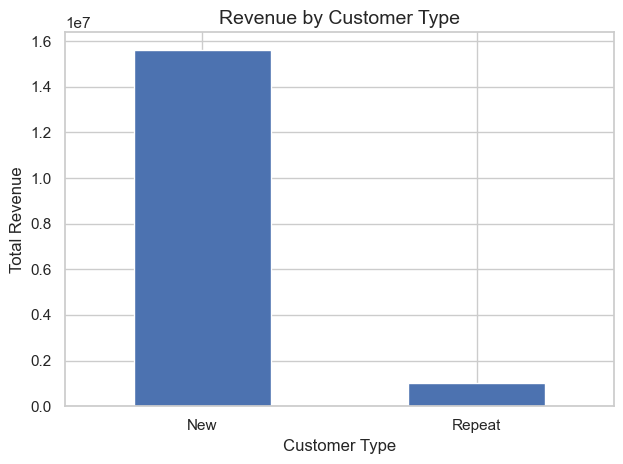

value_segment
Low Value     72072
High Value    24024
Name: count, dtype: int64
value_segment
High Value    10087430.66
Low Value      6518320.37
Name: total_order_value, dtype: float64


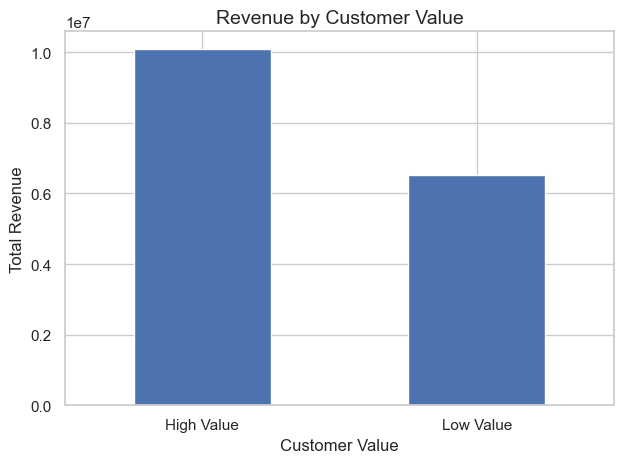

   customer_state  total_order_value
25             SP         6220311.97
18             RJ         2241834.46
10             MG         1924179.12
22             RS          931562.70
17             PR          829406.65
4              BA          649149.63
23             SC          631420.63
8              GO          367880.39
6              DF          365975.23
7              ES          336052.39
15             PE          333655.36
5              CE          290167.15
13             PA          224608.74
12             MT          203768.97
9              MA          155444.21
14             PB          151368.06
11             MS          140034.05
16             PI          114648.34
19             RN          114628.83
1              AL           99781.70


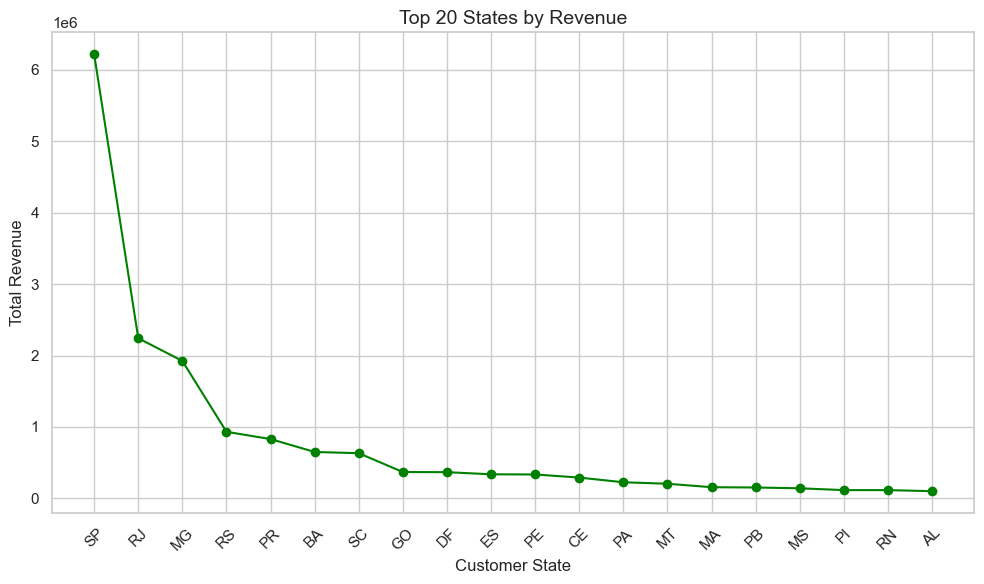

In [280]:
#EDA
import seaborn as sns
import matplotlib.pyplot as plt

# New vs repeat customers 
master_df1["customer_type"] = master_df1["purchase_frequency"].apply(
    lambda x: "New" if x==1 else "Repeat")

customer_type_counts = master_df1["customer_type"].value_counts()
print(customer_type_counts)
# New customers are more which shows good marketing. New customers is contributing to more revenue
# Repeat custmers are less. Business needs to work on retenion of customers to boast revenue

customer_type_level = master_df1[["order_id","customer_type","total_order_value"]].drop_duplicates()
revenue_customer_type = customer_type_level.groupby("customer_type")["total_order_value"].sum()
print(revenue_customer_type)

revenue_customer_type.plot(kind='bar', rot=0)

plt.title("Revenue by Customer Type", fontsize=14)
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

#High vs low value customer
# 25% of High Value customer contribute 61% of total revenue
# 75% of Low Value customer contribute 39% of total revenue
# Low Value customer driving more revenue
customer_value = master_df1[["customer_unique_id","customer_lifetime_value"]].drop_duplicates()
q75 = customer_value["customer_lifetime_value"].quantile(0.75)
customer_value["value_segment"] = customer_value["customer_lifetime_value"].apply(
    lambda x:"High Value" if x > q75 else "Low Value")

print(customer_value["value_segment"].value_counts())
order_level = master_df1.groupby(["order_id","customer_unique_id"],as_index=False)["total_order_value"].first()
order_level = order_level.merge(customer_value, on="customer_unique_id")
revenue_split = order_level.groupby("value_segment")["total_order_value"].sum()
print(revenue_split)

revenue_split.plot(kind="bar",rot=0)
plt.title("Revenue by Customer Value", fontsize=14)
plt.xlabel("Customer Value")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

#  Geographic distribution of customers 
#  Revenue is highly concentrated in a few states, with SP alone contributing the highest share (~₹6.2M), followed by RJ and MG. 
#   Together, the top 3 states account for a significant portion of total revenue.
customer_geo = master_df1.groupby("customer_state")["customer_unique_id"].nunique().reset_index()
customer_geo = customer_geo.sort_values("customer_unique_id",ascending=False)
order_level = master_df1.groupby(["customer_unique_id","order_id","customer_state"],as_index=False)["total_order_value"].first()
customer_geo_revenue = order_level.groupby("customer_state")["total_order_value"].sum().reset_index()
top20_revenue_states = customer_geo_revenue.sort_values("total_order_value",ascending=False).head(20)
print(top20_revenue_states)


plt.figure(figsize=(10,6))

plt.plot(
    top20_revenue_states["customer_state"],
    top20_revenue_states["total_order_value"],
    marker='o',
    color='green'  
)

plt.title("Top 20 States by Revenue", fontsize=14)
plt.xlabel("Customer State")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

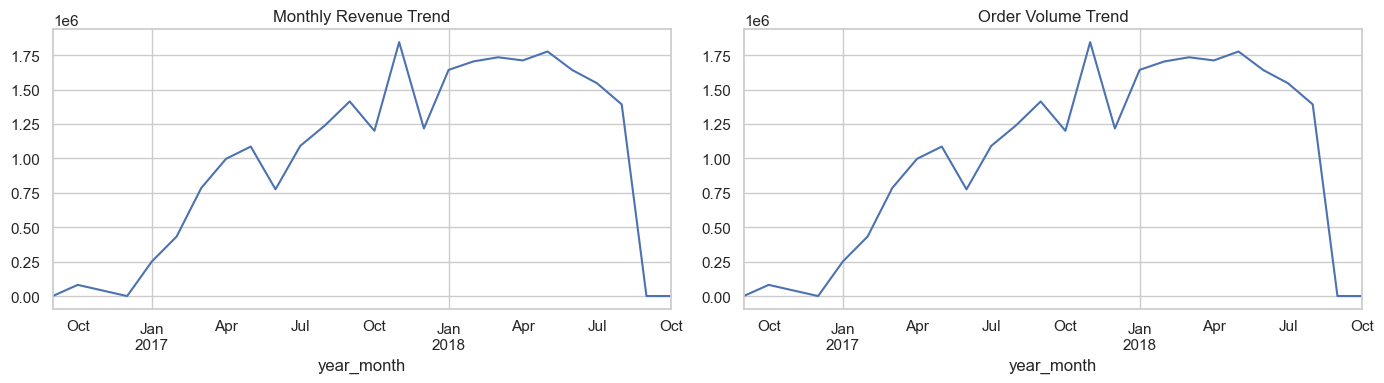

Peak Revenue Month: 2017-11


In [281]:
# Monthly revenue trends 

#There is a sharp peak around late 2017, followed by some fluctuations but overall strong performance into early–mid 2018.
master_df1["year_month"] = master_df1["order_purchase_timestamp"].dt.to_period("M")
monthly_revenue = master_df1.groupby("year_month")["total_order_value"].sum()

fig, axes = plt.subplots(1,2,figsize=(14,4))

monthly_revenue.plot(ax=axes[0], kind="line", title="Monthly Revenue Trend")

# Order volume trends 

order_volume = master_df1.groupby("year_month")["order_id"].nunique()
monthly_revenue.plot(ax=axes[1], kind="line", title="Order Volume Trend")
plt.tight_layout()
plt.show()

# Peak sales periods 
peak_month = order_volume.idxmax()
print("Peak Revenue Month:", peak_month)  # Oct 2017 is peak sales period

product_category_name_english
agro_industry_and_commerce    252
air_conditioning              302
art                           219
arts_and_craftmanship          24
audio                         380
Name: order_item_id, dtype: int64


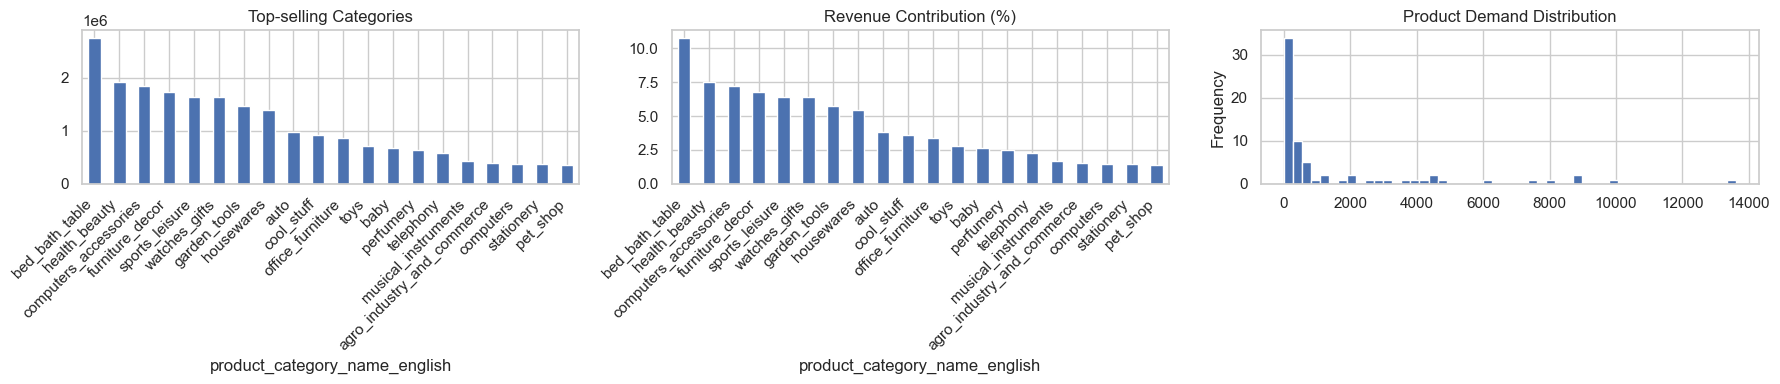

In [282]:
# Top-selling product categories 

fig, axes = plt.subplots(1, 3, figsize=(18,4))

# 1. Revenue
category_revenue = master_df1.groupby("product_category_name_english")["total_order_value"].sum().sort_values(ascending=False)
category_revenue.head(20).plot(ax=axes[0], kind="bar", title="Top-selling Categories")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# 2. Contribution
revenue_contribution = (category_revenue/category_revenue.sum()) * 100
revenue_contribution.head(20).plot(kind='bar', ax=axes[1], title='Revenue Contribution (%)')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

# 3. Demand Distribution
category_demand = master_df1.groupby('product_category_name_english')['order_item_id'].count()
print(category_demand.head())

category_demand.plot(kind='hist', bins=50, ax=axes[2], title='Product Demand Distribution')

plt.tight_layout()
plt.show()

#Bed, Bath & Table, Health & Beauty, and Computers & Accessories lead both in sales and revenue contribution.
#A few top categories contribute a significant share of total revenue, indicating a concentrated sales structure.
#The histogram shows a right-skewed distribution, where most products have low demand while a few products drive very high sales.

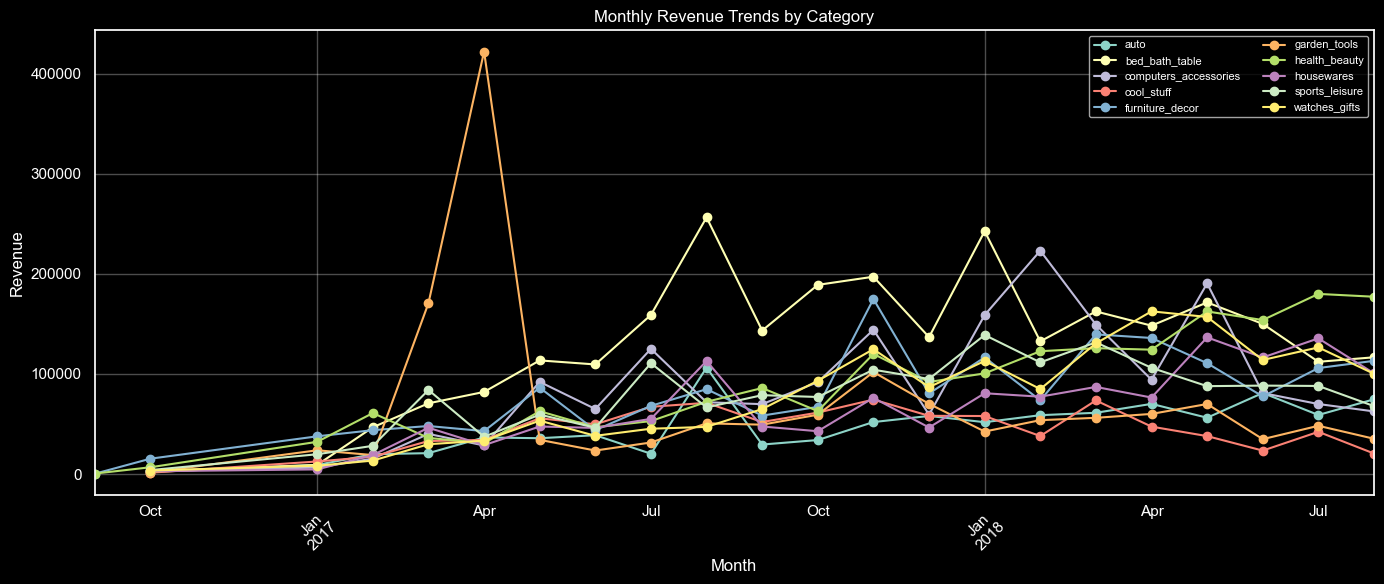

In [283]:


# Top 10 category names
top_10_categories = category_revenue.head(10).index

# Filter + group
monthly_revenue_cat = master_df1[
    master_df1['product_category_name_english'].isin(top_10_categories)
].groupby(['year_month', 'product_category_name_english'])['total_order_value'].sum().unstack()

# ---- Plot ----
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(14, 6))

monthly_revenue_cat.plot(ax=ax, marker='o')

ax.set_title('Monthly Revenue Trends by Category')
ax.set_ylabel('Revenue')
ax.set_xlabel('Month')

ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Health & Beauty and Watches & Gifts emerged as consistent leaders

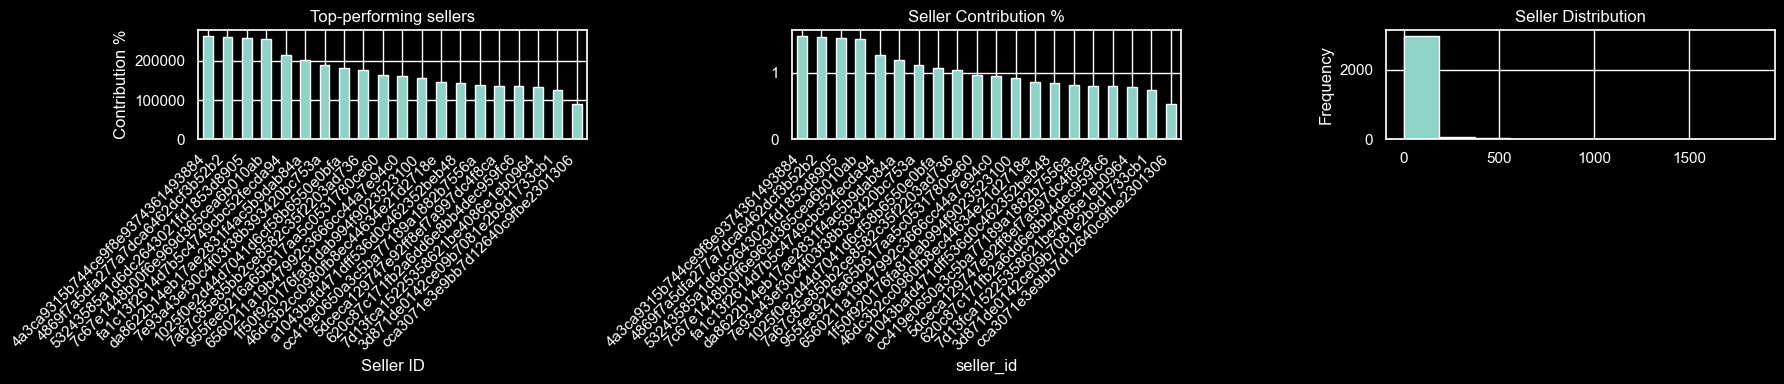

In [284]:
fig, axes = plt.subplots(1,3,figsize=(18,4))

# Top-performing sellers 

seller_level = master_df1.groupby(["seller_id","order_id"],as_index=False)["total_order_value"].first()

best_sellers = seller_level.groupby("seller_id")["total_order_value"].sum().sort_values(ascending=False)

best_sellers.head(20).plot(ax=axes[0],kind="bar",title="Top-performing sellers")
plt.setp(axes[0].get_xticklabels(),rotation=45,ha="right")
axes[0].set_xlabel("Seller ID")
axes[0].set_ylabel("Revenue")

# Seller contribution to revenue

seller_revenue = (best_sellers/best_sellers.sum())*100
seller_revenue = seller_revenue.sort_values(ascending=False)
seller_revenue.head(20).plot(ax=axes[1],kind="bar",title="Seller Contribution %")
plt.setp(axes[1].get_xticklabels(),rotation=45,ha="right")
axes[0].set_xlabel("Seller ID")
axes[0].set_ylabel("Contribution %")


# Seller distribution 
# Many sellers contribute to high revenue which is evenly distributed
seller_distribution = master_df1.groupby("seller_id")["order_id"].nunique()
seller_distribution.plot(ax=axes[2],kind="hist",bins = 10,title = "Seller Distribution")
axes[0].set_xlabel("Seller ID")
axes[0].set_ylabel("Contribution %")

plt.tight_layout()
plt.show()
#The seller distribution is right-skewed, indicating a long-tail pattern 
#where a small number of sellers handle most orders and many sellers handle less orders

review_score
1.0    0.130060
2.0    0.035095
3.0    0.083614
4.0    0.189146
5.0    0.562086
Name: proportion, dtype: float64


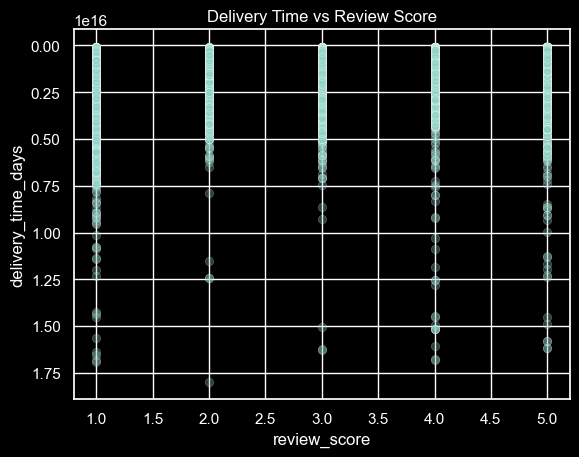

18 days 17:37:06.129216491
product_category_name_english
bed_bath_table           2600
furniture_decor          1653
computers_accessories    1462
health_beauty            1364
sports_leisure           1283
housewares               1128
watches_gifts            1002
telephony                 784
garden_tools              738
auto                      657
Name: count, dtype: int64
seller_id
4a3ca9315b744ce9f8e9374361493884    419
7c67e1448b00f6e969d365cea6b010ab    410
6560211a19b47992c3666cc44a7e94c0    376
1f50f920176fa81dab994f9023523100    360
cc419e0650a3c5ba77189a1882b7556a    286
1025f0e2d44d7041d6cf58b6550e0bfa    282
da8622b14eb17ae2831f4ac5b9dab84a    243
955fee9216a65b617aa5c0531780ce60    216
ea8482cd71df3c1969d7b9473ff13abc    203
cca3071e3e9bb7d12640c9fbe2301306    182
Name: count, dtype: int64
is_bad_review
False   11 days 10:05:07.052053321
True    18 days 17:37:06.129216491
Name: delivery_time_days, dtype: timedelta64[ns]


In [285]:
#	Distribution of review scores 

#56% of reviews are 5-star — a strong positive signal, but masking underlying issues
review_level = master_df1["review_score"].value_counts(normalize=True).sort_index()
print(review_level)

#	Relationship between delivery time and ratings 

sns.scatterplot(x="review_score", y="delivery_time_days", alpha=0.3, data=master_df1)
plt.title("Delivery Time vs Review Score")
plt.show()

review_level = master_df1[['delivery_time_days', 'review_score']].dropna()
review_level['delivery_time_days'].corr(review_level['review_score'])

#Correlation between review_score and delivery_time_days is -0.30 which indicates moderate negative relationship
# If delivery takes more days, it impacts the review score
# Other factors may also be influencing review scores, and delivery time alone does not fully explain customer satisfaction.

#	Identification of dissatisfaction patterns 

#low rating orders

bad_review = master_df1[master_df1["review_score"] <= 2]


#Average delivery delay in bad reviews, Average shows 18 days contributing to bad reviews

print(bad_review["delivery_time_days"].mean())

#Most complained categories, Show product quality contributing to bad reviews

print(bad_review["product_category_name_english"].value_counts().head(10))

#Sellers with most complaints, bad reviews due to missing or wrong items
print(bad_review['seller_id'].value_counts().head(10))

master_df1["is_bad_review"] = master_df1["review_score"] <= 2

print(master_df1.groupby("is_bad_review")["delivery_time_days"].mean())

C:\Users\Deepa\AppData\Local\Temp\ipykernel_21432\2423628487.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_trend = master_df1.resample('M', on='order_purchase_timestamp')['total_order_value'].sum()


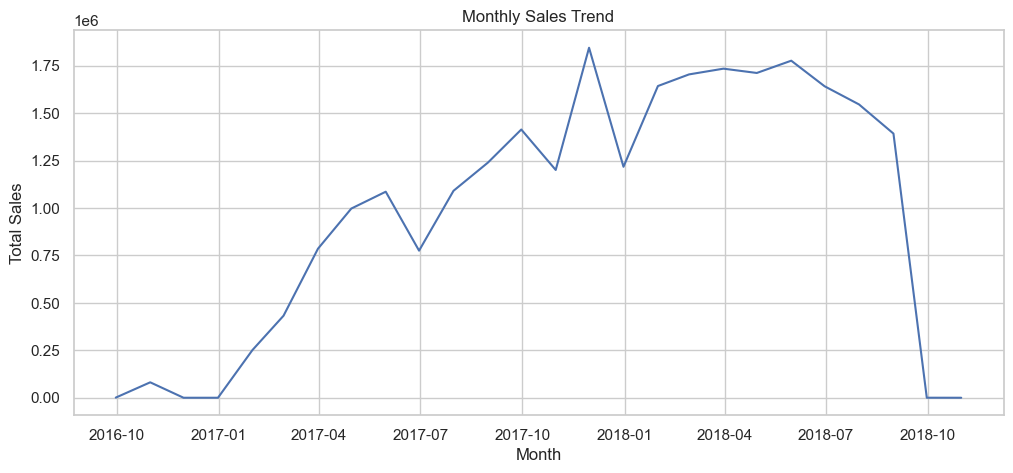

In [286]:
#	Time series plots (sales trends) 
sns.set(style="whitegrid")
sales_trend = master_df1.resample('M', on='order_purchase_timestamp')['total_order_value'].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_trend.index, sales_trend.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

# Oct 2017 is peak sales period

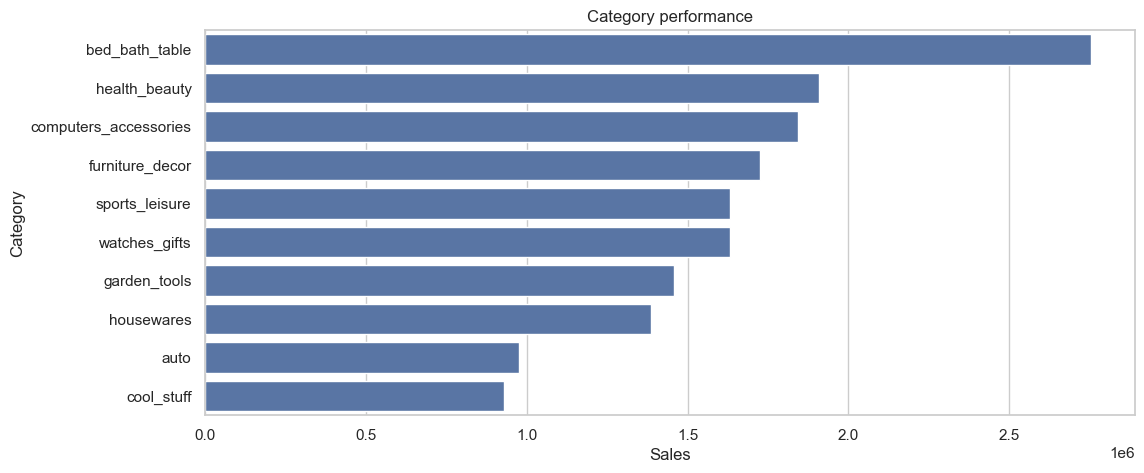

In [287]:
category_sales = master_df1.groupby('product_category_name_english')['total_order_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title("Category performance")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.show()

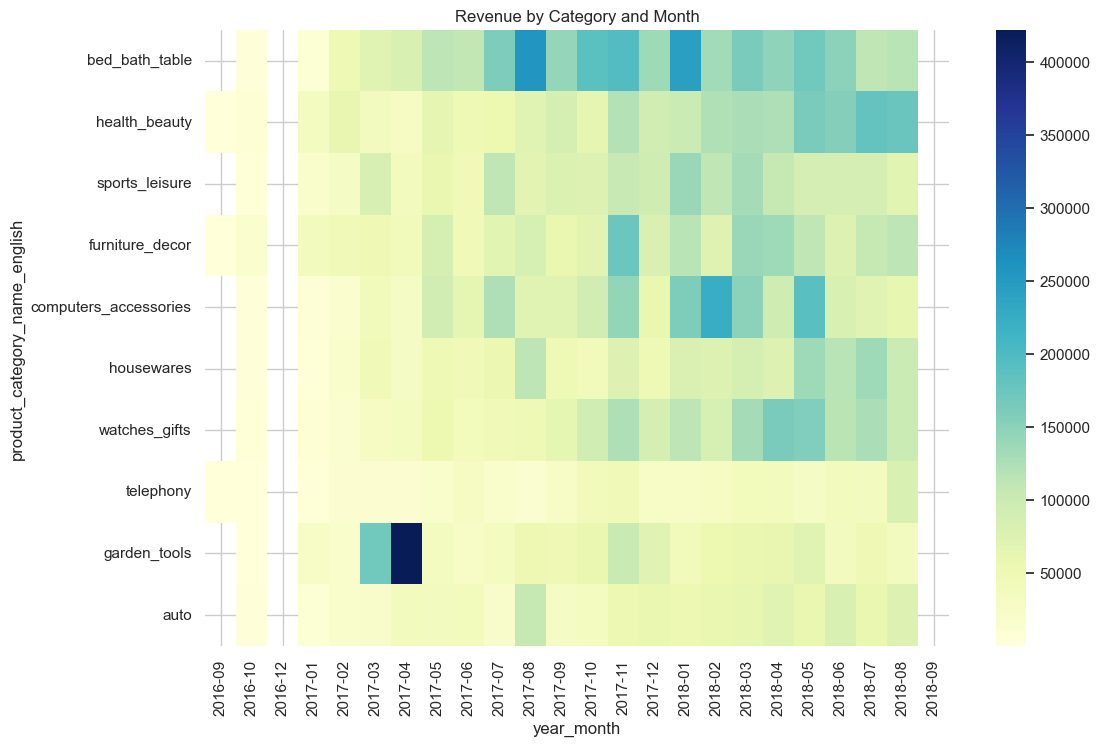

In [288]:
pivot = master_df1.pivot_table(
    index='product_category_name_english',
    columns='year_month',
    values='total_order_value',
    aggfunc='sum'
)
top_categories = master_df1['product_category_name_english'].value_counts().head(10).index
pivot = pivot.loc[top_categories]
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Revenue by Category and Month')
plt.show()